In [3]:
import matplotlib.pyplot as plt

In [1]:
# Testing objective function output

import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np


## Inputs
eq = desc.io.load("desc_eq_beta2.5_QA.h5")
# rhos = np.sqrt(np.linspace(0.1,0.9,20)) # rho = sqrt(s)
rhos = np.linspace(0.1,0.9,15)
alphas = np.linspace(0,2*np.pi,2)
KE_frac = np.array([1]) 
pitch_invs = np.linspace(5.8,5.9,2)
N=0
num_transit = 6
wd_blur = 1.2
##

In [2]:
obj = TrappedResonance(eq,rho=rhos,pitch_invs=pitch_invs,KE_frac=KE_frac,alpha=alphas,N=N,n_max=1,num_transit=num_transit,wd_blur=wd_blur)
obj.build()
value = obj.compute(eq.params_dict)

Precomputing transforms


In [ ]:
# Plot field line
from desc.integrals.bounce_integral import Bounce1D

eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid = eq._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rhos, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.linspace(0,2*np.pi*4,10), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)

data = eq.compute(
    Bounce1D.required_names + ["min_tz |B|", "max_tz |B|", "g_zz"], grid=grid
)
# Make the bounce integration operator.
bounce1 = Bounce1D(grid.source_grid, data, check=True)
pitch_inv, _ = bounce1.get_pitch_inv_quad(
    min_B=grid.compress(data["min_tz |B|"]),
    max_B=grid.compress(data["max_tz |B|"]),
    num_pitch=5, # currently pitch is manually set in this function
)
l=0
m=0
fig, ax = bounce1.plot(l, m, pitch_inv[l], include_legend=False, show=True) # field line plot

In [4]:
# Average ignoring zero values
from desc.utils import safediv
def npmean_nz(x,axis=0):
    mask = x!=0.0
    count = np.sum(mask,axis) # how many wells that are not 0
    return safediv(np.sum(x,axis=axis) , count)
    # return np.sum(x,axis=axis) / count

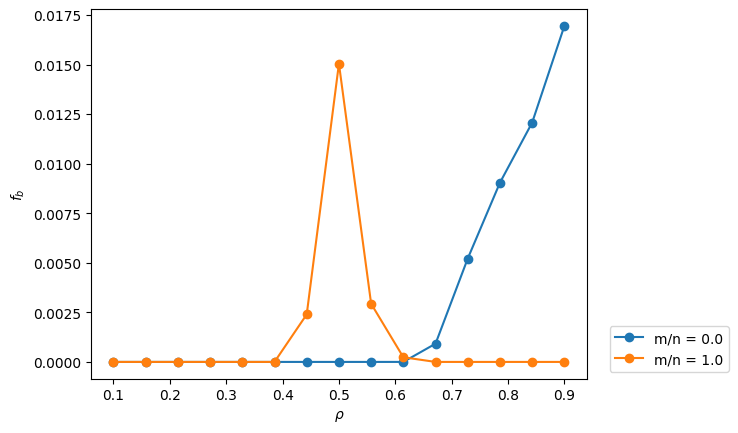

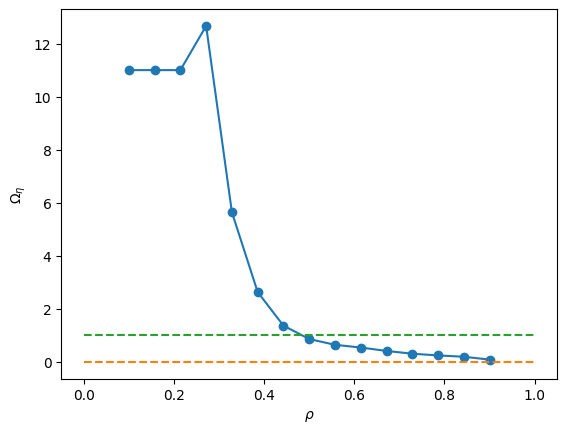

In [5]:
# 1. Is f_b doing what we want it to do?

omega_arr = value['omega_arr'] # := (rho,Bc,well)
# omega_arr = npmean_nz(omega_arr,axis=-1) # := (rho,Bc)
# omega_arr = omega_arr[:,0] # := (rho)
omega_arr = omega_arr[:,0,0] # := (rho)

rhos = value['rhos'] # := (rho,well)
rhos = npmean_nz(rhos,axis=-1) # := (rho)

f_b = value['f_b'] # := (rho,Bc,well,res)
# f_b = npmean_nz(f_b,axis=-2) # := (rho,Bc,res)
# f_b = f_b[:,0,:] # := (rho,res)
f_b = f_b[:,0,0,:] # := (rho,res)

res_arr = value['res_arr'] # := (res)

fig1,ax1 = plt.subplots()
for i in range(0,f_b.shape[-1]):
    # if res_arr[i] != np.pi or res_arr[i] == 0 or res_arr[i] == 1:
    if res_arr[i] == 0 or res_arr[i] == 1:
        ax1.plot(rhos,f_b[:,i],'-o',label='m/n = '+str(res_arr[i]))

# ax1.set_xlabel(r'$\Omega_\eta$')
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel(r'$f_b$')
ax1.legend(loc='lower right',bbox_to_anchor=(1.3, 0))

fig,ax = plt.subplots()
ax.plot(rhos,omega_arr,'-o')
ax.set_xlabel(r'$\rho$')
ax.set_ylabel(r'$\Omega_\eta$')
ax.plot([0,1],[0,0],'--')
ax.plot([0,1],[1,1],'--')

In [ ]:
print(rhos)